![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


### Current Process & Its Limitations

Today, loan applications at FinTech Innovations' partner banks are decided through **manual review by loan officers**. Each officer reads through an applicant's financials and uses their own judgment (with internal guidelines) to approve or deny the loan. This has three concrete limitations:

- **Inconsistency** — two officers can reach different conclusions on similar applicants, since judgment varies by individual experience and interpretation of guidelines.
- **Speed** — manual review doesn't scale; as application volume grows, turnaround time to the applicant grows with it.
- **Auditability** — when a decision is challenged (by an applicant, a regulator, or internal audit), it's hard to point to a precise, repeatable reason "why" beyond an individual officer's notes.

A standardized, data-driven model addresses all three: it applies the same criteria to every applicant, decides in milliseconds, and produces a documented, reproducible reason for every decision.

### Key Stakeholders

| Stakeholder | What they need from this model |
|---|---|
| **Applicants** | A fast, consistent, and fair decision — and (for denials) a clear, defensible reason, since fair-lending law generally requires one. |
| **Loan officers / underwriters** | A decision-support score they can trust and override when their own judgment disagrees, not a black box that replaces their job. |
| **Risk / Credit Risk team** | Minimal exposure to defaults — they care most about not approving bad loans. |
| **Compliance / Legal** | A model that is explainable and doesn't discriminate on protected characteristics (fair-lending / ECOA exposure). |
| **FinTech Innovations & partner banks** | A standardized process that works the same way across every partner bank, reducing branch-to-branch inconsistency. |
| **Executive leadership** | Loan volume/revenue growth, balanced against risk — speed and consistency are a competitive advantage as long as losses don't spike. |

### Cost of Model Errors

The business has quantified both error types, and they are far from symmetric:

| Error | Meaning | Business cost |
|---|---|---|
| **False Negative** — deny a creditworthy applicant | We turn away someone who would have repaid the loan | **$8,000** average profit lost per missed good loan |
| **False Positive** — approve an applicant who defaults | We fund a loan that is never repaid | **$50,000** average loss per defaulted loan (principal + collection costs) |

A false positive costs **6.25x** more than a false negative ($50,000 ÷ $8,000). This asymmetry is the single most important fact shaping how this model should be built and tuned: it is far better, in dollar terms, to be conservative — occasionally turning away a good applicant — than to be lenient and occasionally fund a default. Optimizing purely for accuracy would ignore this and treat both error types as equally bad, which they clearly are not.

### Classification vs. Regression

We're framing this as a **classification problem** (predicting `LoanApproved`, 0/1) rather than a regression problem (predicting a continuous default-risk score), for one concrete data reason: **there's no clean regression target available**. The dataset's continuous-looking `RiskScore` column turns out to be a near-perfect function of `LoanApproved` itself (a single cutoff on it reproduces the approval decision 96% of the time) rather than an independent measurement of how the loan actually performed after origination (e.g., an observed default outcome). Using it as a regression target would mean predicting a number that's already a stand-in for the label we're trying to learn — not genuinely new information.

`LoanApproved` is also the more directly actionable target for this business: it mirrors the decision loan officers already make today, so a classifier's output (its predicted *probability* of approval, not just a hard 0/1) can be used two ways — automating routine decisions outright, or handing officers a risk-ranked score to prioritize and support manual review, exactly as the business asked for.

### Modeling Goals & Success Criteria

Given the cost asymmetry above, accuracy alone is the wrong success criterion — a model that always predicts "Deny" would hit ~76% accuracy (matching the dataset's class split) while producing zero loans and zero business value. We'll use multiple metrics, each chosen for a specific reason:

- **ROC-AUC** — measures how well the model ranks risky vs. creditworthy applicants independent of where we set the approval cutoff. This is our primary metric for comparing models, since the right cutoff is a business decision we can make separately.
- **Precision & Recall (on the "Approved" class)** — precision tells us, of everyone we approve, how many are actually good; recall tells us how much good business we're capturing. Given the cost asymmetry, we care more about precision than recall.
- **F1-score** — a standard balance of the two, reported for comparability with typical classification benchmarks.
- **Custom metric — Expected Net Portfolio Value ($).** Using the actual costs given by the business, we convert every model's confusion matrix into a single dollar figure:
  - True Positive (good loan correctly approved): **+$8,000**
  - False Positive (bad loan approved, defaults): **−$50,000**
  - False Negative (good loan wrongly denied): **−$8,000** (the profit we missed out on)
  - True Negative (bad loan correctly denied): **$0**
  - **Net Value = (TP × $8,000) − (FP × $50,000) − (FN × $8,000)**

  This metric translates model performance directly into the language the stakeholders above actually care about.

**Baseline targets.** Two naive baselines set the floor any real model must beat:
- *Always deny:* 0% recall, ~76% accuracy, but **$0** net value — no loans, no business.
- *Always approve:* high recall, ~24% accuracy, and a **deeply negative** net value, since every bad loan (the majority of applicants) costs $50,000.

Our goal is a model that is comfortably better than both: an ROC-AUC meaningfully above 0.5 (targeting ≥ 0.85), and — more importantly to the business — a substantially positive Net Portfolio Value that beats the always-deny baseline by a wide margin, confirming the model is genuinely safe to act on.

## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [1]:
# Imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from scipy import stats


# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid")


# Set global DPI for higher-quality renders
plt.rcParams['figure.dpi'] = 300

# Set global font family and size
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12

# Enable grid lines by default
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5


In [2]:
# EDA Code Here - Create New Cells As Needed

# Loading the data
df = pd.read_csv('financial_loan_data.csv')
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
print("Shape:", df.shape)
display(df.info(verbose=True))

Shape: (20000, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpen

None

In [4]:
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,19428.000000,20000.000000,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,0.285735,0.100050,23.993650,14.957300,4949.148446,1782.555100,9.696440e+04,3.625241e+04,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,0.160211,0.300074,4.945436,8.371552,6628.404969,2245.378812,1.207999e+05,4.725151e+04,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,0.001720,0.000000,8.000000,1.000000,73.000000,24.000000,2.098000e+03,3.720000e+02,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,0.161035,0.000000,21.000000,8.000000,1542.000000,551.000000,3.118025e+04,1.119675e+04,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,0.264454,0.000000,24.000000,15.000000,2988.500000,1116.000000,6.069900e+04,2.220300e+04,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,0.390327,0.000000,27.000000,22.000000,5869.250000,2126.000000,1.174052e+05,4.314650e+04,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,0.902253,1.000000,45.000000,29.000000,200089.000000,52572.000000,2.619627e+06,1.417302e+06,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [5]:
# Checking datatypes
display(df.dtypes.to_frame("dtype"))


,dtype
Age,int64
AnnualIncome,object
CreditScore,int64
EmploymentStatus,object
EducationLevel,object
Experience,int64
LoanAmount,int64
LoanDuration,int64
MaritalStatus,object
NumberOfDependents,int64


In [6]:
df["AnnualIncome"] = (
    df["AnnualIncome"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [7]:
#checking missing values
display(df.isna().sum().to_frame())


,0
Age,0
AnnualIncome,0
CreditScore,0
EmploymentStatus,0
EducationLevel,901
Experience,0
LoanAmount,0
LoanDuration,0
MaritalStatus,1331
NumberOfDependents,0


In [8]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# Unique value counts
display(df.nunique().sort_values(ascending=True).to_frame("unique_values"))


,unique_values
PreviousLoanDefaults,2
BankruptcyHistory,2
LoanApproved,2
EmploymentStatus,3
HomeOwnershipStatus,4
MaritalStatus,4
EducationLevel,5
LoanPurpose,5
NumberOfDependents,6
NumberOfCreditInquiries,8


In [10]:
df['EducationLevel'].value_counts()

EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
Name: count, dtype: int64

,Count,Proportion
LoanApproved,,
0,15220,0.761
1,4780,0.239


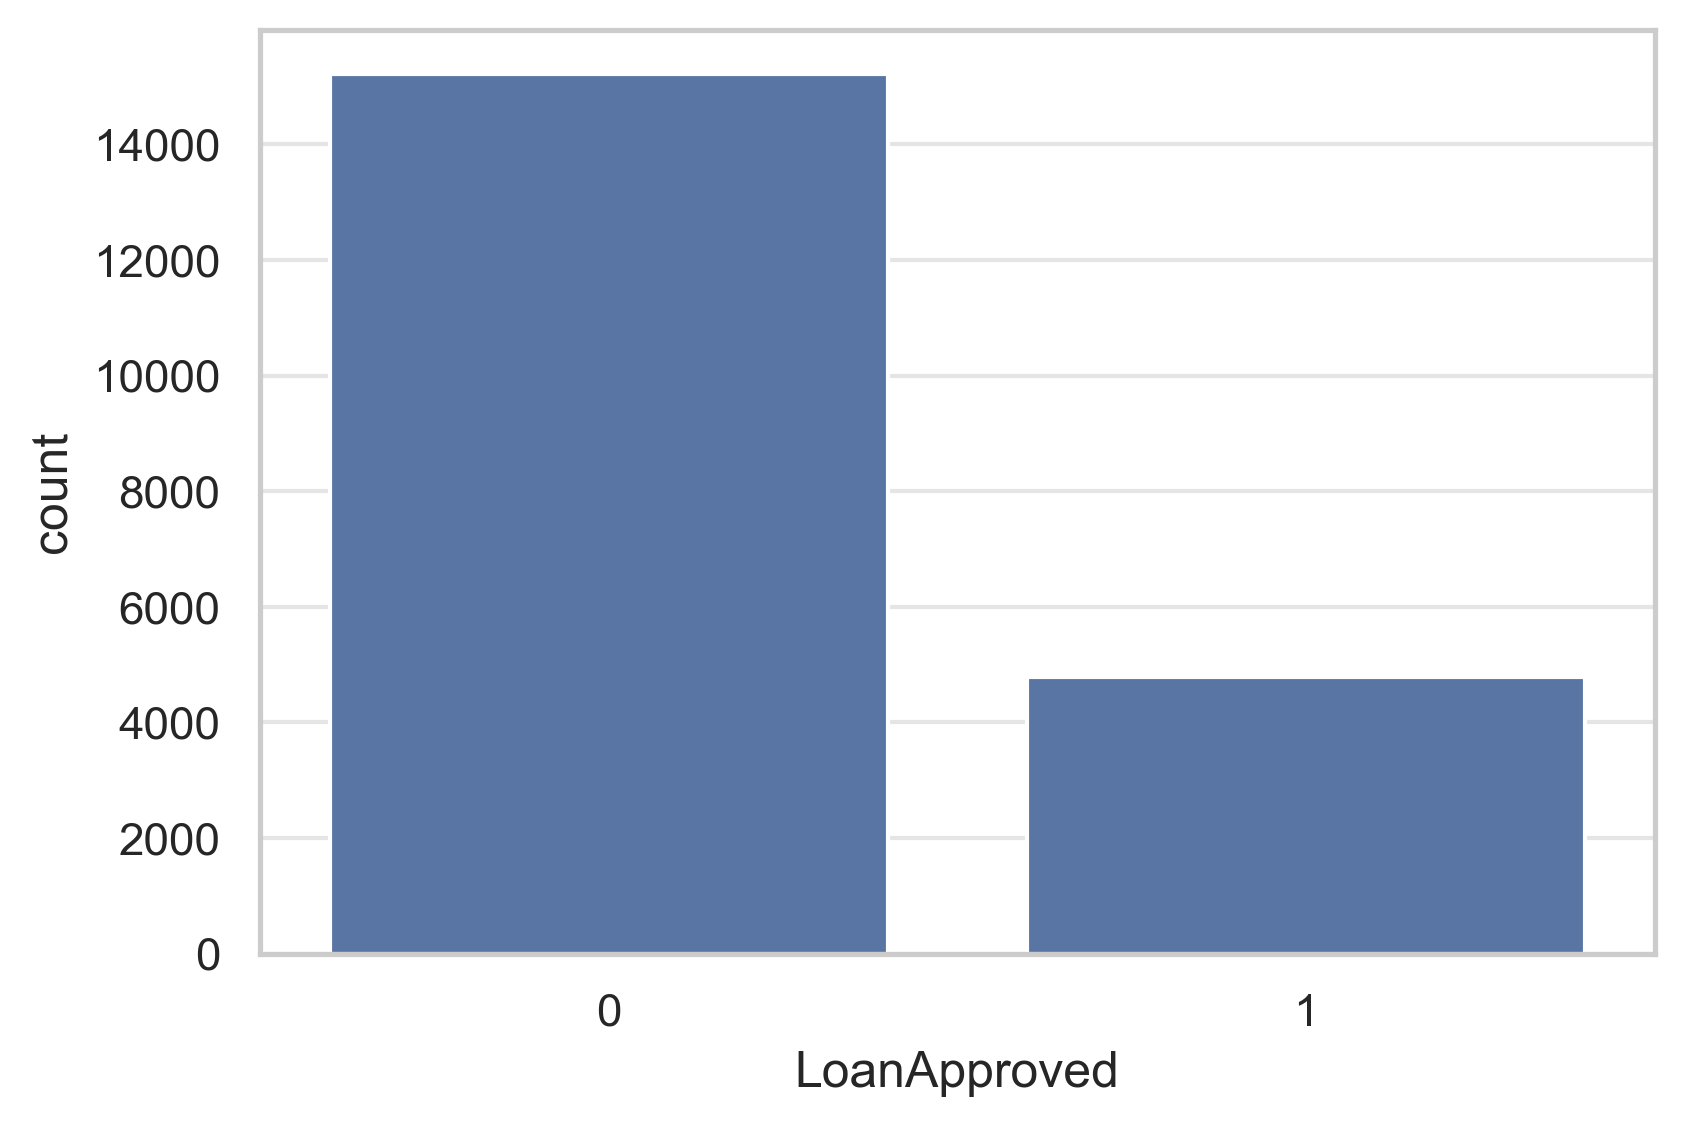

In [11]:
# Target variable Exploration

target_count = df['LoanApproved'].value_counts()
target_rates = df['LoanApproved'].value_counts(normalize=True)

target_summary = pd.concat([target_count, target_rates], axis=1)
target_summary.columns = ["Count", "Proportion"]
display(target_summary)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='LoanApproved')
# ax.set_title()
# ax.set_xlabel()
# ax.set_ylabel()
plt.show()



In [12]:
num_cols = df.select_dtypes(include=np.number).columns

# n_cols = 3
# n_rows = int(np.ceil((len(num_cols)) / n_cols))

# fig, axes = plt.subplots(n_rows, n_cols, figsize= (18, 4 * n_rows))
# axes = axes.flatten()

# for i, col in enumerate(df.columns):
#     sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    
# for j in range(i + 1, len(axes)):
#     axes[j].axis("off")
    
# plt.tight_layout()
# plt.show()

In [13]:
# Boxplots to inspect outliers and spread

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [14]:

numeric_features = [
    "Age",
    "AnnualIncome",
    "CreditScore",
    "Experience",
    "LoanAmount",
    "LoanDuration",
    "MonthlyDebtPayments",
    "CreditCardUtilizationRate",
    "NumberOfOpenCreditLines",
    "NumberOfCreditInquiries",
    "DebtToIncomeRatio",
    "LengthOfCreditHistory",
    "SavingsAccountBalance",
    "CheckingAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "MonthlyIncome",
    "JobTenure",
    "NetWorth",
    "InterestRate",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

nominal_features = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

ordinal_feature = "EducationLevel"

binary_features = [
    "BankruptcyHistory",
    "PreviousLoanDefaults",
]

# combined categorical features
cat_features = nominal_features + binary_features


In [15]:
#preprocessing pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

education_order = [
    [
        "High School",
        "Associate",
        "Bachelor",
        "Master",
        "Doctorate"
    ]
]

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=education_order))
])

In [16]:
# ColumnTransformer: assign numeric, categorical (nominal+binary), and ordinal pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, cat_features),
        ("ord", ordinal_pipeline, [ordinal_feature]),
    ]
)


In [17]:
# Fit the preprocessor and transform the DataFrame
df_processed_array = preprocessor.fit_transform(df)

# Build feature names for the transformed output. sklearn >=1.0 provides get_feature_names_out
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    # Fallback: try to assemble names from transformers
    num_names = list(numeric_features)
    try:
        ohe = preprocessor.named_transformers_['cat'].named_steps['encoder']
        cat_names = list(ohe.get_feature_names_out(cat_features))
    except Exception:
        cat_names = list(cat_features)
    ord_names = [ordinal_feature]
    feature_names = num_names + cat_names + ord_names

# Convert to DataFrame so we can call isna() and other pandas ops
df_processed = pd.DataFrame(df_processed_array, columns=feature_names)


In [18]:
display(df_processed.isna().sum().to_frame())


,0
num__Age,0
num__AnnualIncome,0
num__CreditScore,0
num__Experience,0
num__LoanAmount,0
num__LoanDuration,0
num__MonthlyDebtPayments,0
num__CreditCardUtilizationRate,0
num__NumberOfOpenCreditLines,0
num__NumberOfCreditInquiries,0


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


### Choosing Our Metrics

Looking at the target column, about **24% of applicants are approved** and **76% are denied**. Since the classes are not balanced, accuracy alone can be misleading — a model that just predicts "Denied" every time would still be right about 76% of the time without learning anything useful.

There are two ways a model can be wrong:
- **False Positive**: we approve someone who should have been denied. This is risky for the bank because the loan could default and the bank loses money.
- **False Negative**: we deny someone who should have been approved. This means the bank misses out on profit from a good customer.

The business has given us real numbers for these two mistakes:
- Denying a good applicant (False Negative) costs an average of **$8,000** in lost profit.
- Approving an applicant who defaults (False Positive) costs an average of **$50,000** (principal + collection costs).

Since a False Positive is over 6x more expensive than a False Negative, approving a bad loan is far more costly than missing out on a good one. So we'll look at more than just accuracy:
- **Accuracy** — overall correctness (reported, but not our main metric)
- **Precision** — out of everyone we approved, how many were actually good applicants
- **Recall** — out of everyone who should have been approved, how many we actually approved
- **F1-score** — a balance between precision and recall
- **ROC-AUC** — how well the model separates good applicants from bad ones, no matter what cutoff we use

**Custom metric:** using the real dollar figures above, we'll turn every model's confusion matrix into a single estimated profit number — $8,000 for every correctly approved loan (True Positive), -$50,000 for every wrongly approved loan that defaults (False Positive), and -$8,000 for every good applicant we wrongly turn away (False Negative). This is a single number that's easy to explain to a manager.

In [ ]:
# Real figures given by the business
PROFIT_PER_GOOD_LOAN = 8000     # average profit if a good loan is approved (also the cost if we wrongly deny one)
LOSS_PER_DEFAULTED_LOAN = 50000  # average loss if a bad loan is approved and defaults

def estimated_profit(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp * PROFIT_PER_GOOD_LOAN - fp * LOSS_PER_DEFAULTED_LOAN - fn * PROFIT_PER_GOOD_LOAN

### Train/Test Split

We split the data into a training set (80%) and a test set (20%). We train and tune our models only on the training set, and save the test set for the very end so we get an honest idea of how well the model works on data it hasn't seen before.

We also drop `RiskScore` from the features. Checking the correlation, `RiskScore` is almost perfectly tied to `LoanApproved` (a single cutoff on `RiskScore` predicts the outcome correctly 96% of the time!), which means it was probably used to make the approval decision in the first place. Using it as an input would be "cheating" — the model wouldn't really be learning anything.

In [20]:
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

X = df.drop(columns=["LoanApproved", "RiskScore"])
y = df["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (16000, 33)
Test set size: (4000, 33)


### Our 4 Models

We'll try four different classification algorithms and see which works best:

- **Logistic Regression** — a simple, easy-to-explain model that works well as a first baseline.
- **Decision Tree** — splits the data into yes/no questions; easy to visualize and explain.
- **SVM (Support Vector Machine)** — tries to find the best boundary between approved and denied applicants.
- **AdaBoost** — combines many "weak" simple decision trees into one stronger model.

We pass `class_weight="balanced"` to the models that support it so they don't just learn to predict "Denied" all the time because of the class imbalance we saw earlier.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor), ("clf", model)])
    for name, model in models.items()
}

list(pipelines.keys())

['Logistic Regression', 'Decision Tree', 'SVM', 'AdaBoost']

### Comparing the Models with Cross-Validation

Before tuning anything, let's see how each model performs "out of the box" using 5-fold cross-validation on the training set. `cross_validate` lets us check both **accuracy** and **ROC-AUC** at the same time.

In [22]:
scoring = ["accuracy", "roc_auc"]

baseline_scores = {}
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)
    baseline_scores[name] = {
        "accuracy": scores["test_accuracy"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
    }

baseline_df = pd.DataFrame(baseline_scores).T
display(baseline_df.round(4))

,accuracy,roc_auc
Logistic Regression,0.9550,0.9942
Decision Tree,0.8903,0.8469
SVM,0.9504,0.9926
AdaBoost,0.9292,0.9775


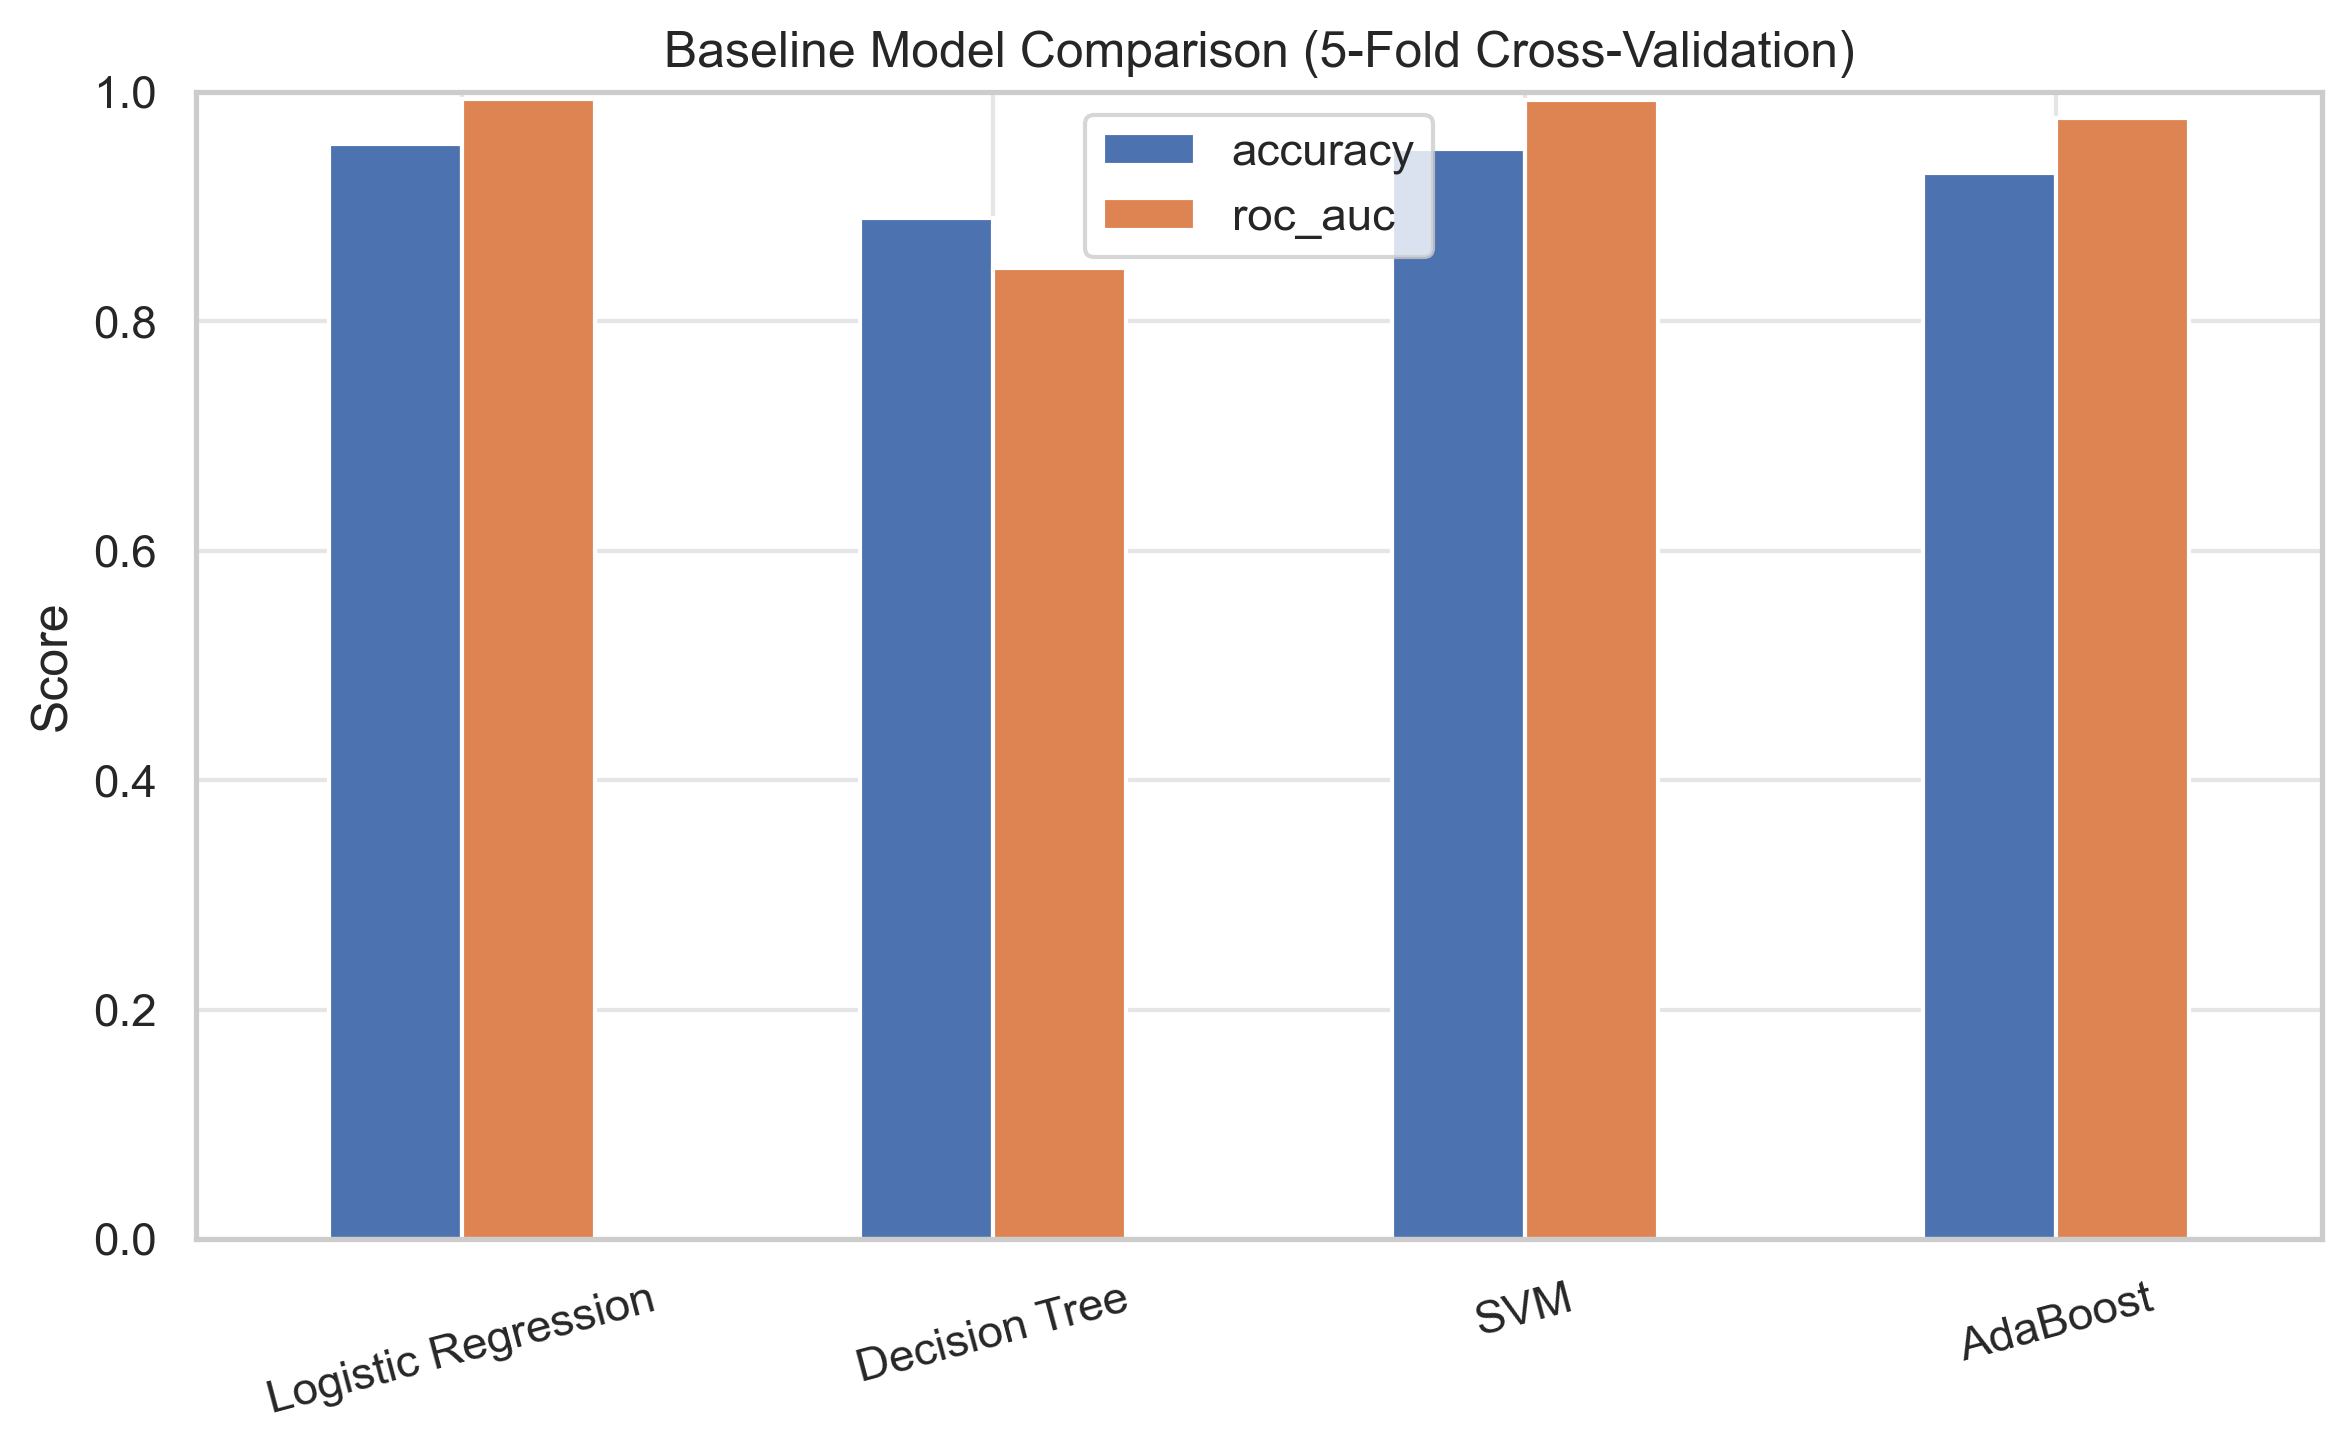

In [23]:
baseline_df.plot(kind="bar", figsize=(8, 5))
plt.title("Baseline Model Comparison (5-Fold Cross-Validation)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Tuning Our Models with GridSearchCV

Now let's try to improve each model by testing a few different hyperparameter values with `GridSearchCV`. We keep the grids small so this doesn't take too long to run.

In [24]:
param_grids = {
    "Logistic Regression": {"clf__C": [0.1, 1, 10]},
    "Decision Tree": {"clf__max_depth": [5, 10, None]},
    "SVM": {"clf__C": [1, 10]},
    "AdaBoost": {"clf__n_estimators": [50, 100]},
}

best_models = {}

for name, pipe in pipelines.items():
    grid = GridSearchCV(pipe, param_grids[name], scoring="roc_auc", cv=5)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"{name}: best params = {grid.best_params_}, best ROC-AUC = {grid.best_score_:.4f}")

Logistic Regression: best params = {'clf__C': 10}, best ROC-AUC = 0.9942


Decision Tree: best params = {'clf__max_depth': 5}, best ROC-AUC = 0.9411


SVM: best params = {'clf__C': 1}, best ROC-AUC = 0.9926


AdaBoost: best params = {'clf__n_estimators': 100}, best ROC-AUC = 0.9858


### Comparing the Tuned Models

Let's check how much the tuning actually helped, using the same 5-fold cross-validation setup as before.

,accuracy,roc_auc
Logistic Regression,0.9559,0.9942
Decision Tree,0.8753,0.9411
SVM,0.9504,0.9926
AdaBoost,0.9439,0.9858


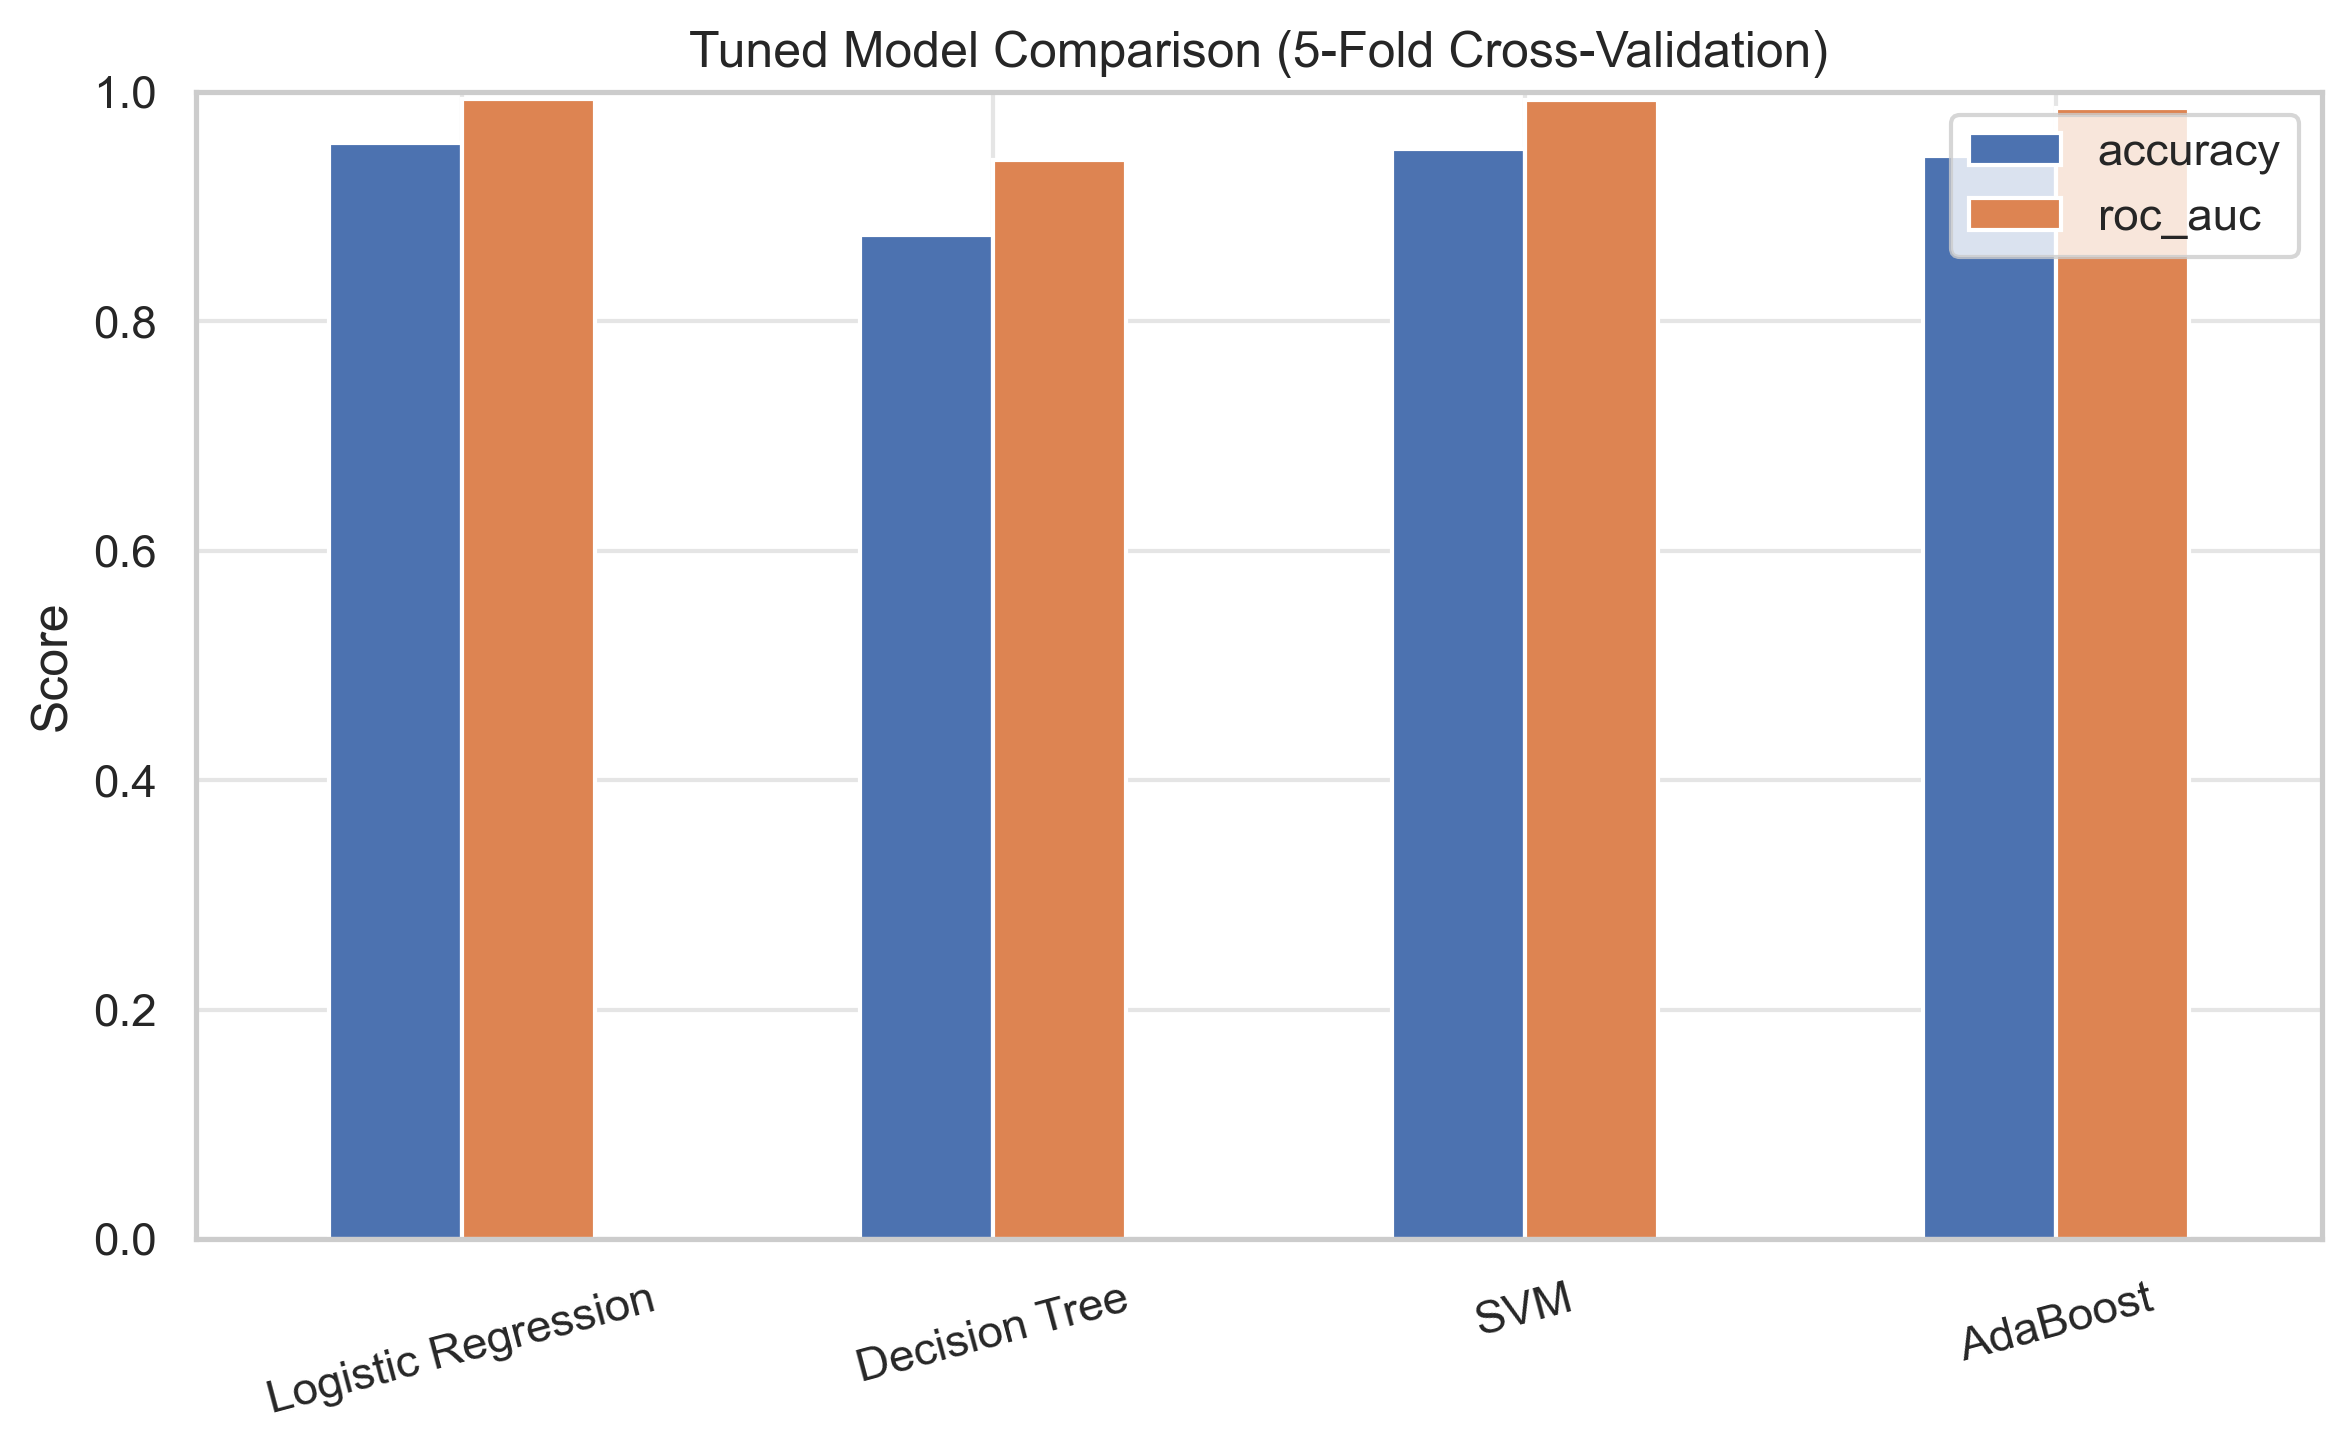

In [25]:
tuned_scores = {}
for name, pipe in best_models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)
    tuned_scores[name] = {
        "accuracy": scores["test_accuracy"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
    }

tuned_df = pd.DataFrame(tuned_scores).T
display(tuned_df.round(4))

tuned_df.plot(kind="bar", figsize=(8, 5))
plt.title("Tuned Model Comparison (5-Fold Cross-Validation)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

### Checking Performance on the Test Set

Now we use the test set (the data we held back) to see how each tuned model really performs on data it has never seen.

In [26]:
test_scores = {}
predictions = {}

for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred

    test_scores[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

test_df = pd.DataFrame(test_scores).T
display(test_df.round(4))

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.9578,0.8709,0.9665,0.9162,0.9942
Decision Tree,0.8772,0.6870,0.8933,0.7767,0.9468
SVM,0.9542,0.8543,0.9749,0.9106,0.9940
AdaBoost,0.9475,0.8977,0.8808,0.8891,0.9870


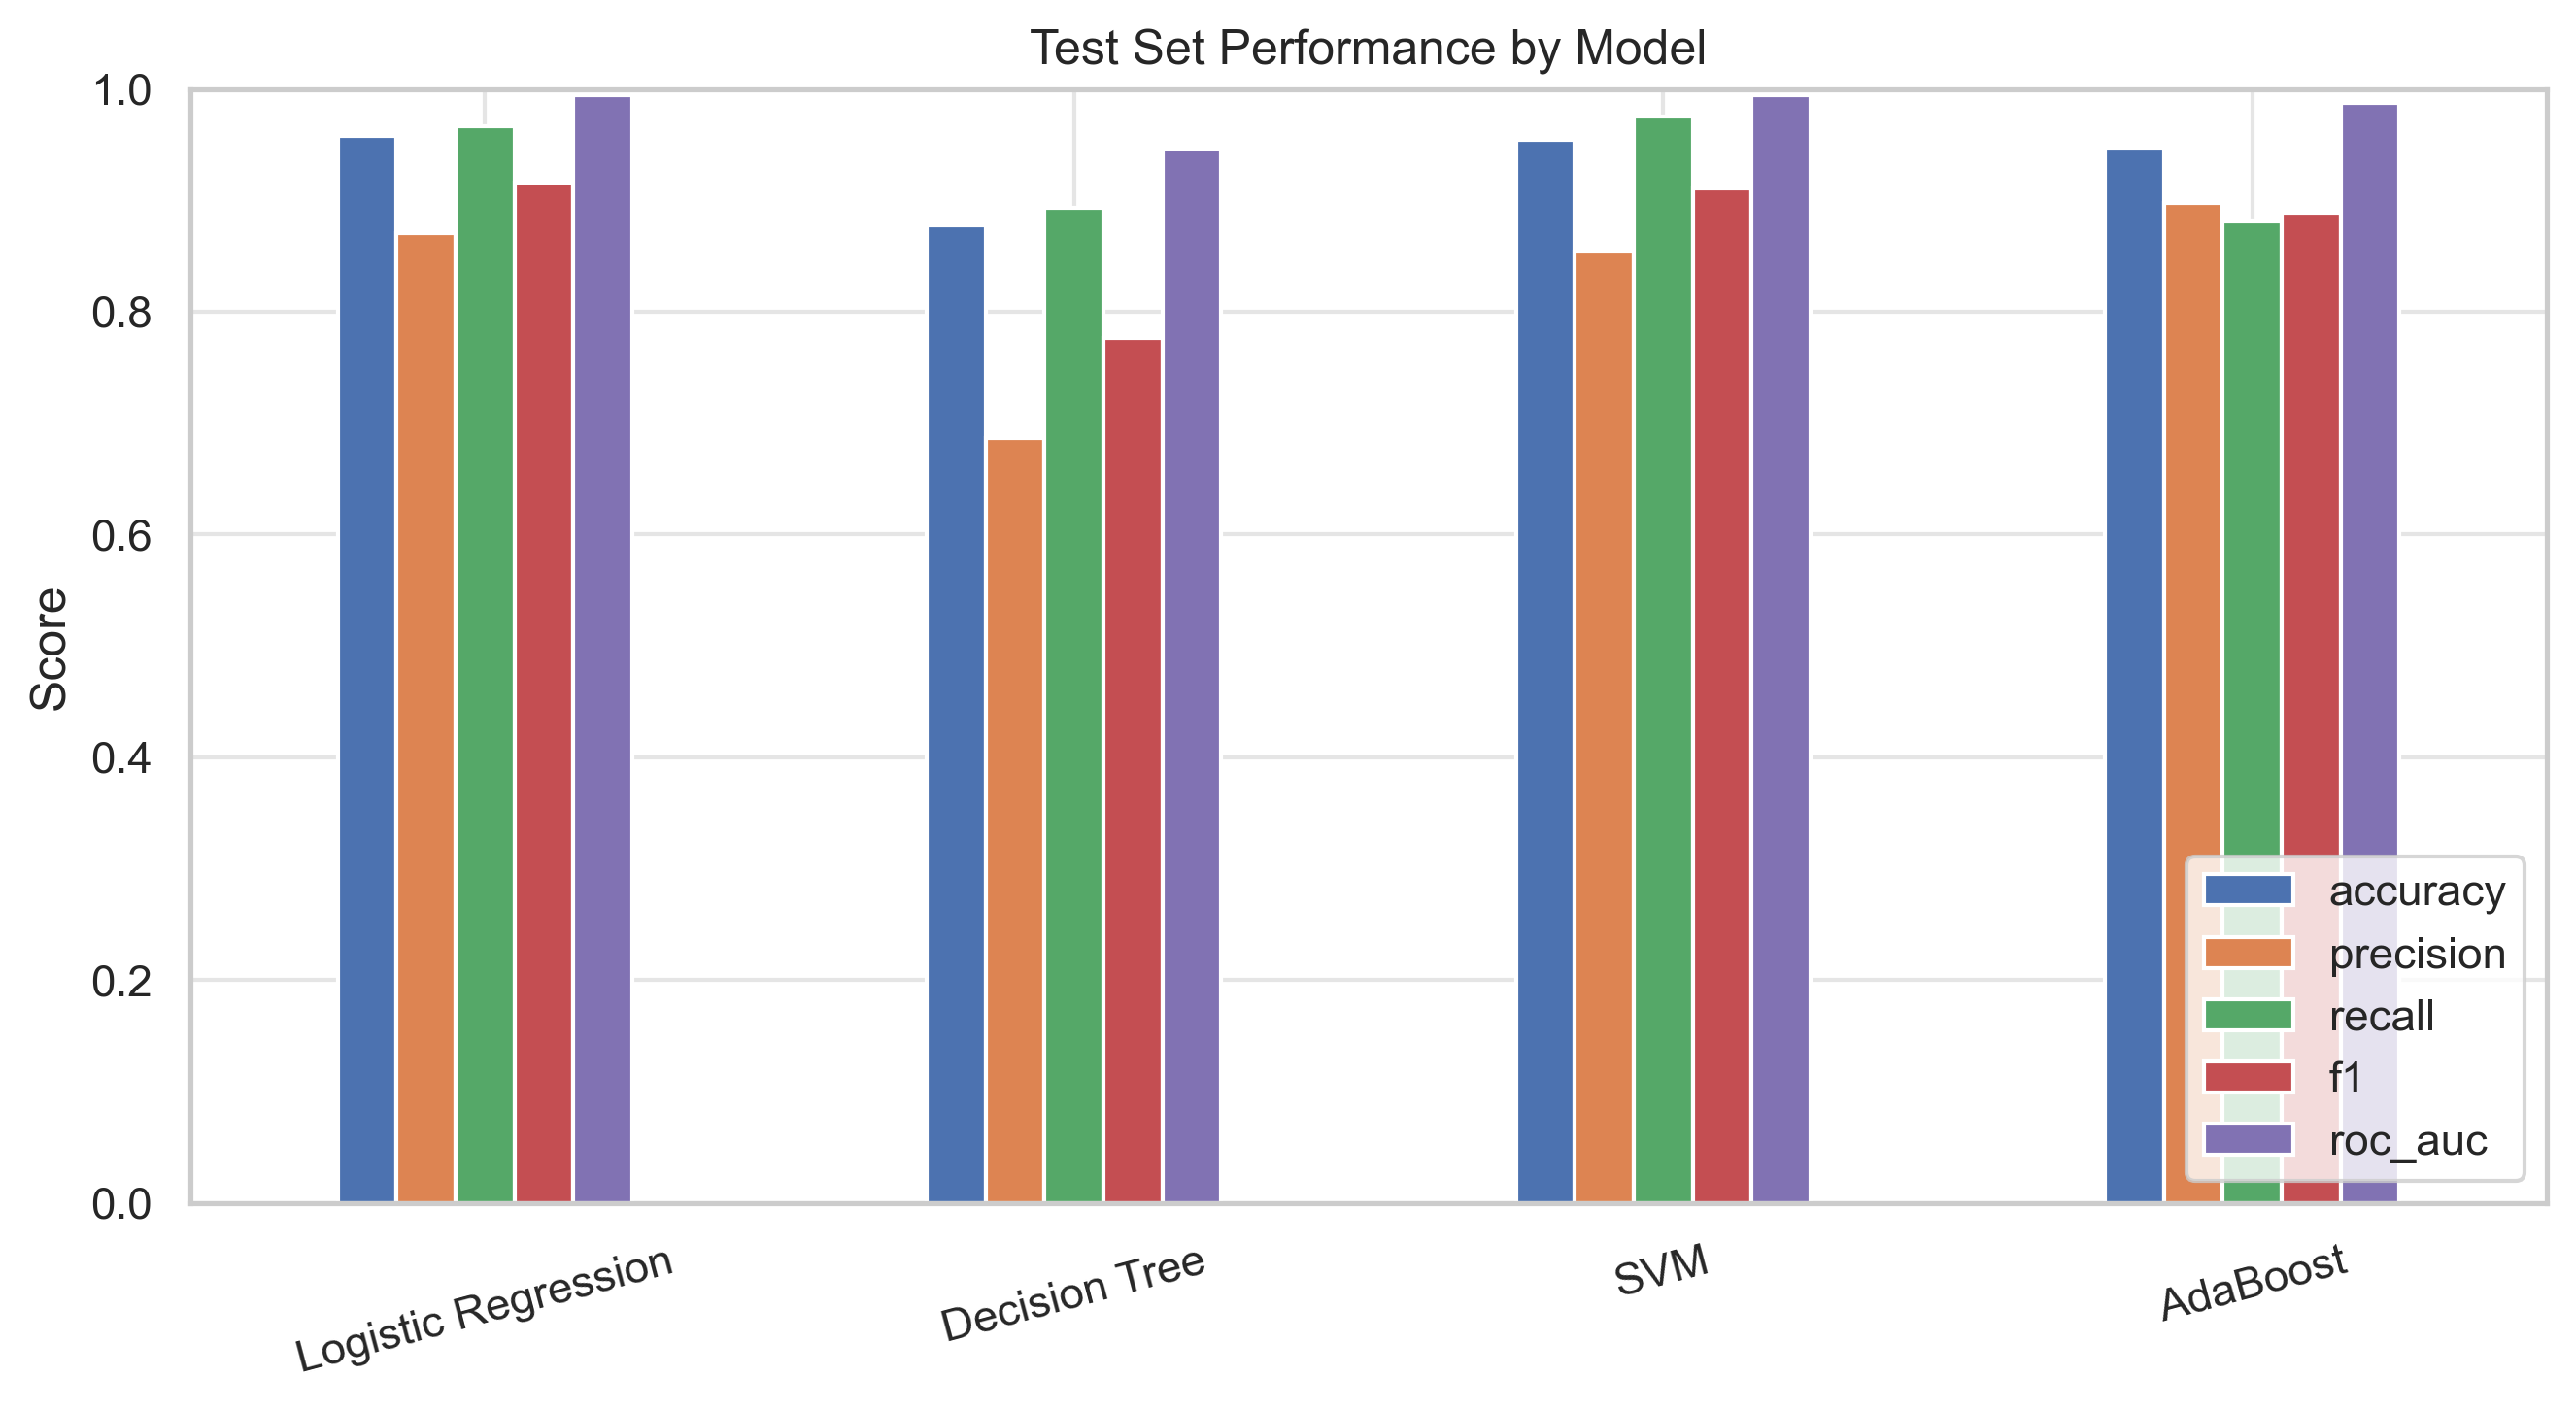

In [27]:
test_df.plot(kind="bar", figsize=(9, 5))
plt.title("Test Set Performance by Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

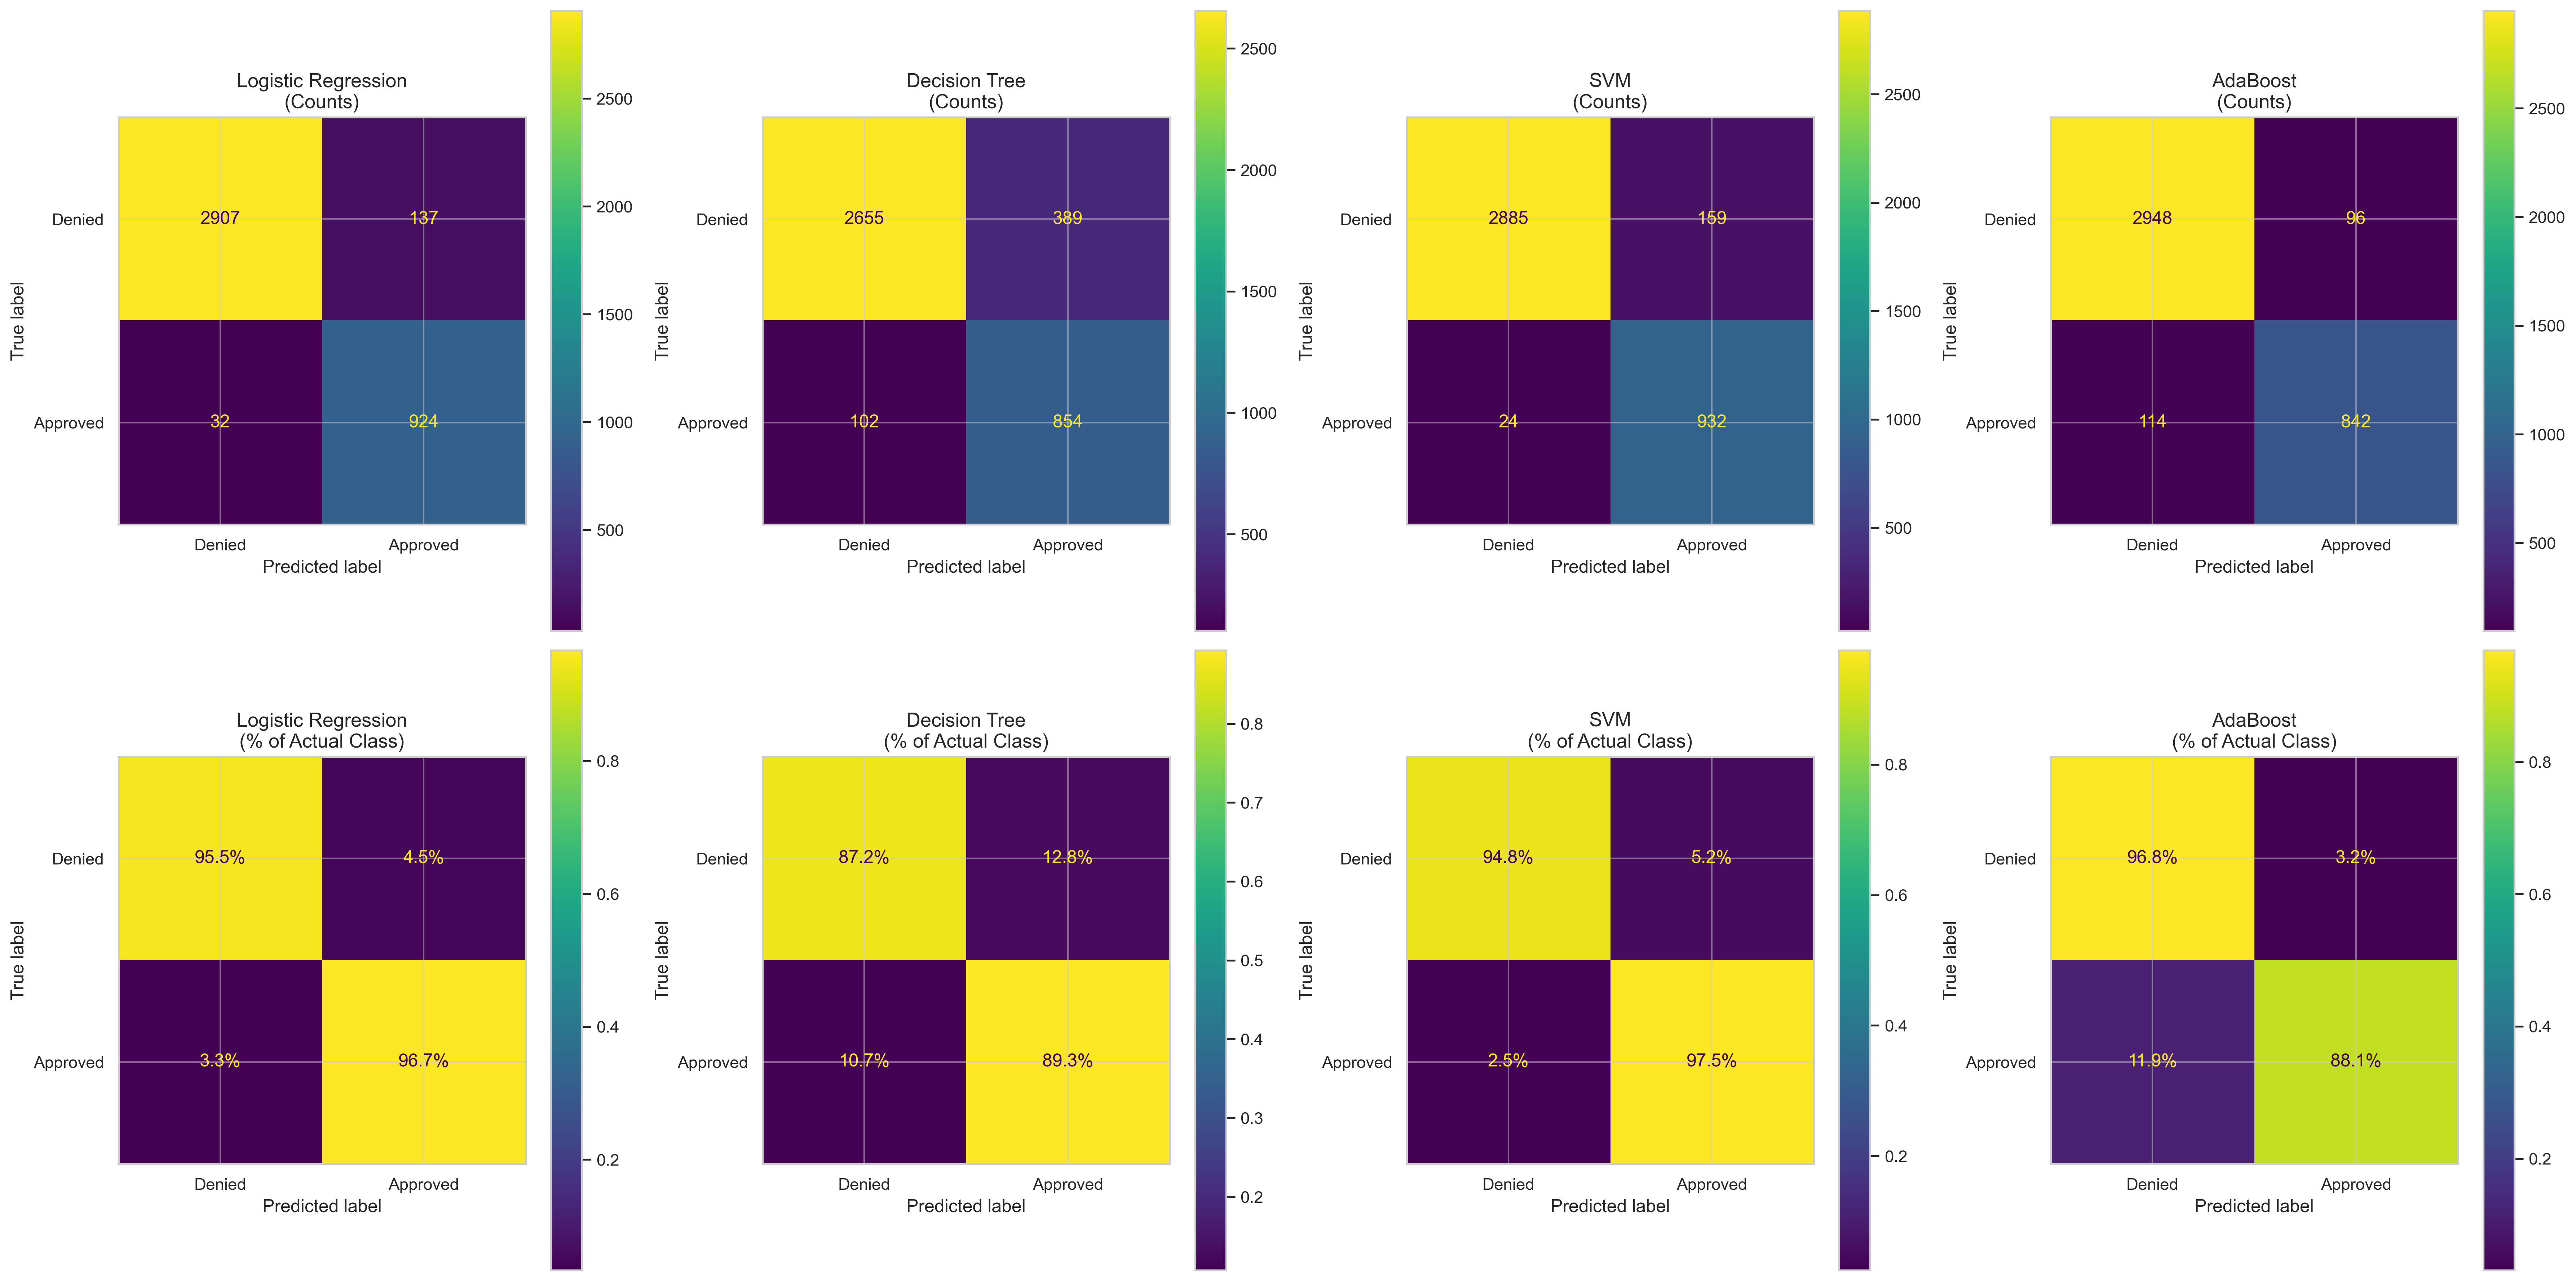

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for col, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = confusion_matrix(y_test, y_pred, normalize="true")

    ConfusionMatrixDisplay(cm, display_labels=["Denied", "Approved"]).plot(
        ax=axes[0, col], colorbar=True, values_format="d"
    )
    axes[0, col].set_title(f"{name}\n(Counts)", fontsize=13)

    ConfusionMatrixDisplay(cm_pct, display_labels=["Denied", "Approved"]).plot(
        ax=axes[1, col], colorbar=True, values_format=".1%"
    )
    axes[1, col].set_title(f"{name}\n(% of Actual Class)", fontsize=13)

plt.tight_layout()
plt.show()

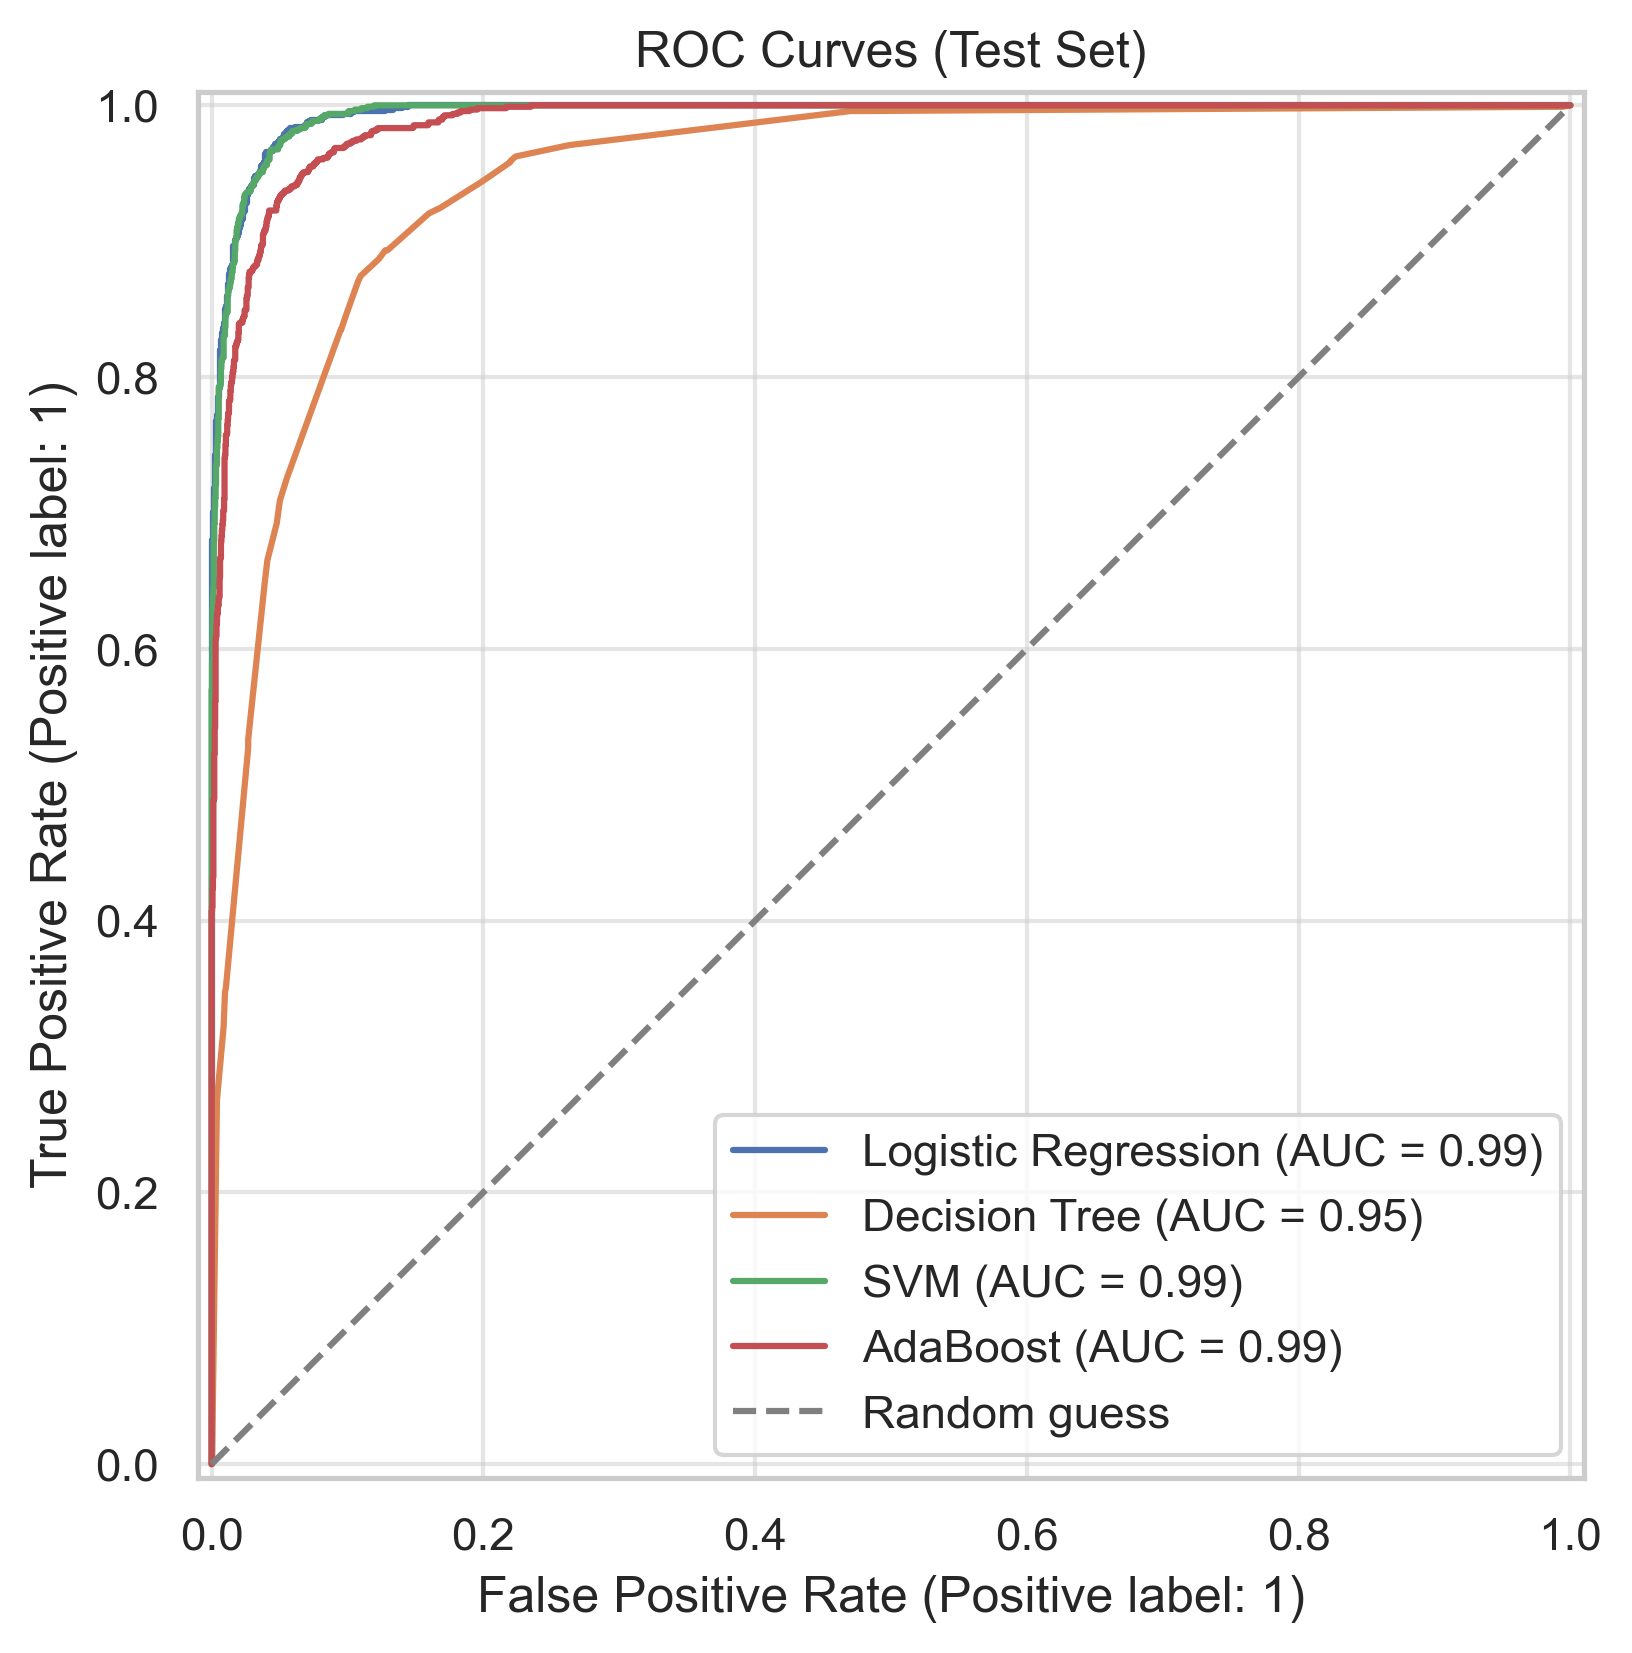

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
ax.set_title("ROC Curves (Test Set)")
ax.legend()
plt.show()

### Our Profit Metric

Using the `estimated_profit` function we wrote earlier in the Modeling section, let's turn each model's confusion matrix into a single estimated dollar number, using the business's real figures: every correctly approved loan earns the bank $8,000, every wrongly approved loan that defaults costs $50,000, and every good applicant we wrongly turn away costs $8,000 in lost profit.

AdaBoost                362000
Logistic Regression     239000
SVM                     137000
Decision Tree         -1091000
Name: Estimated Profit ($), dtype: int64

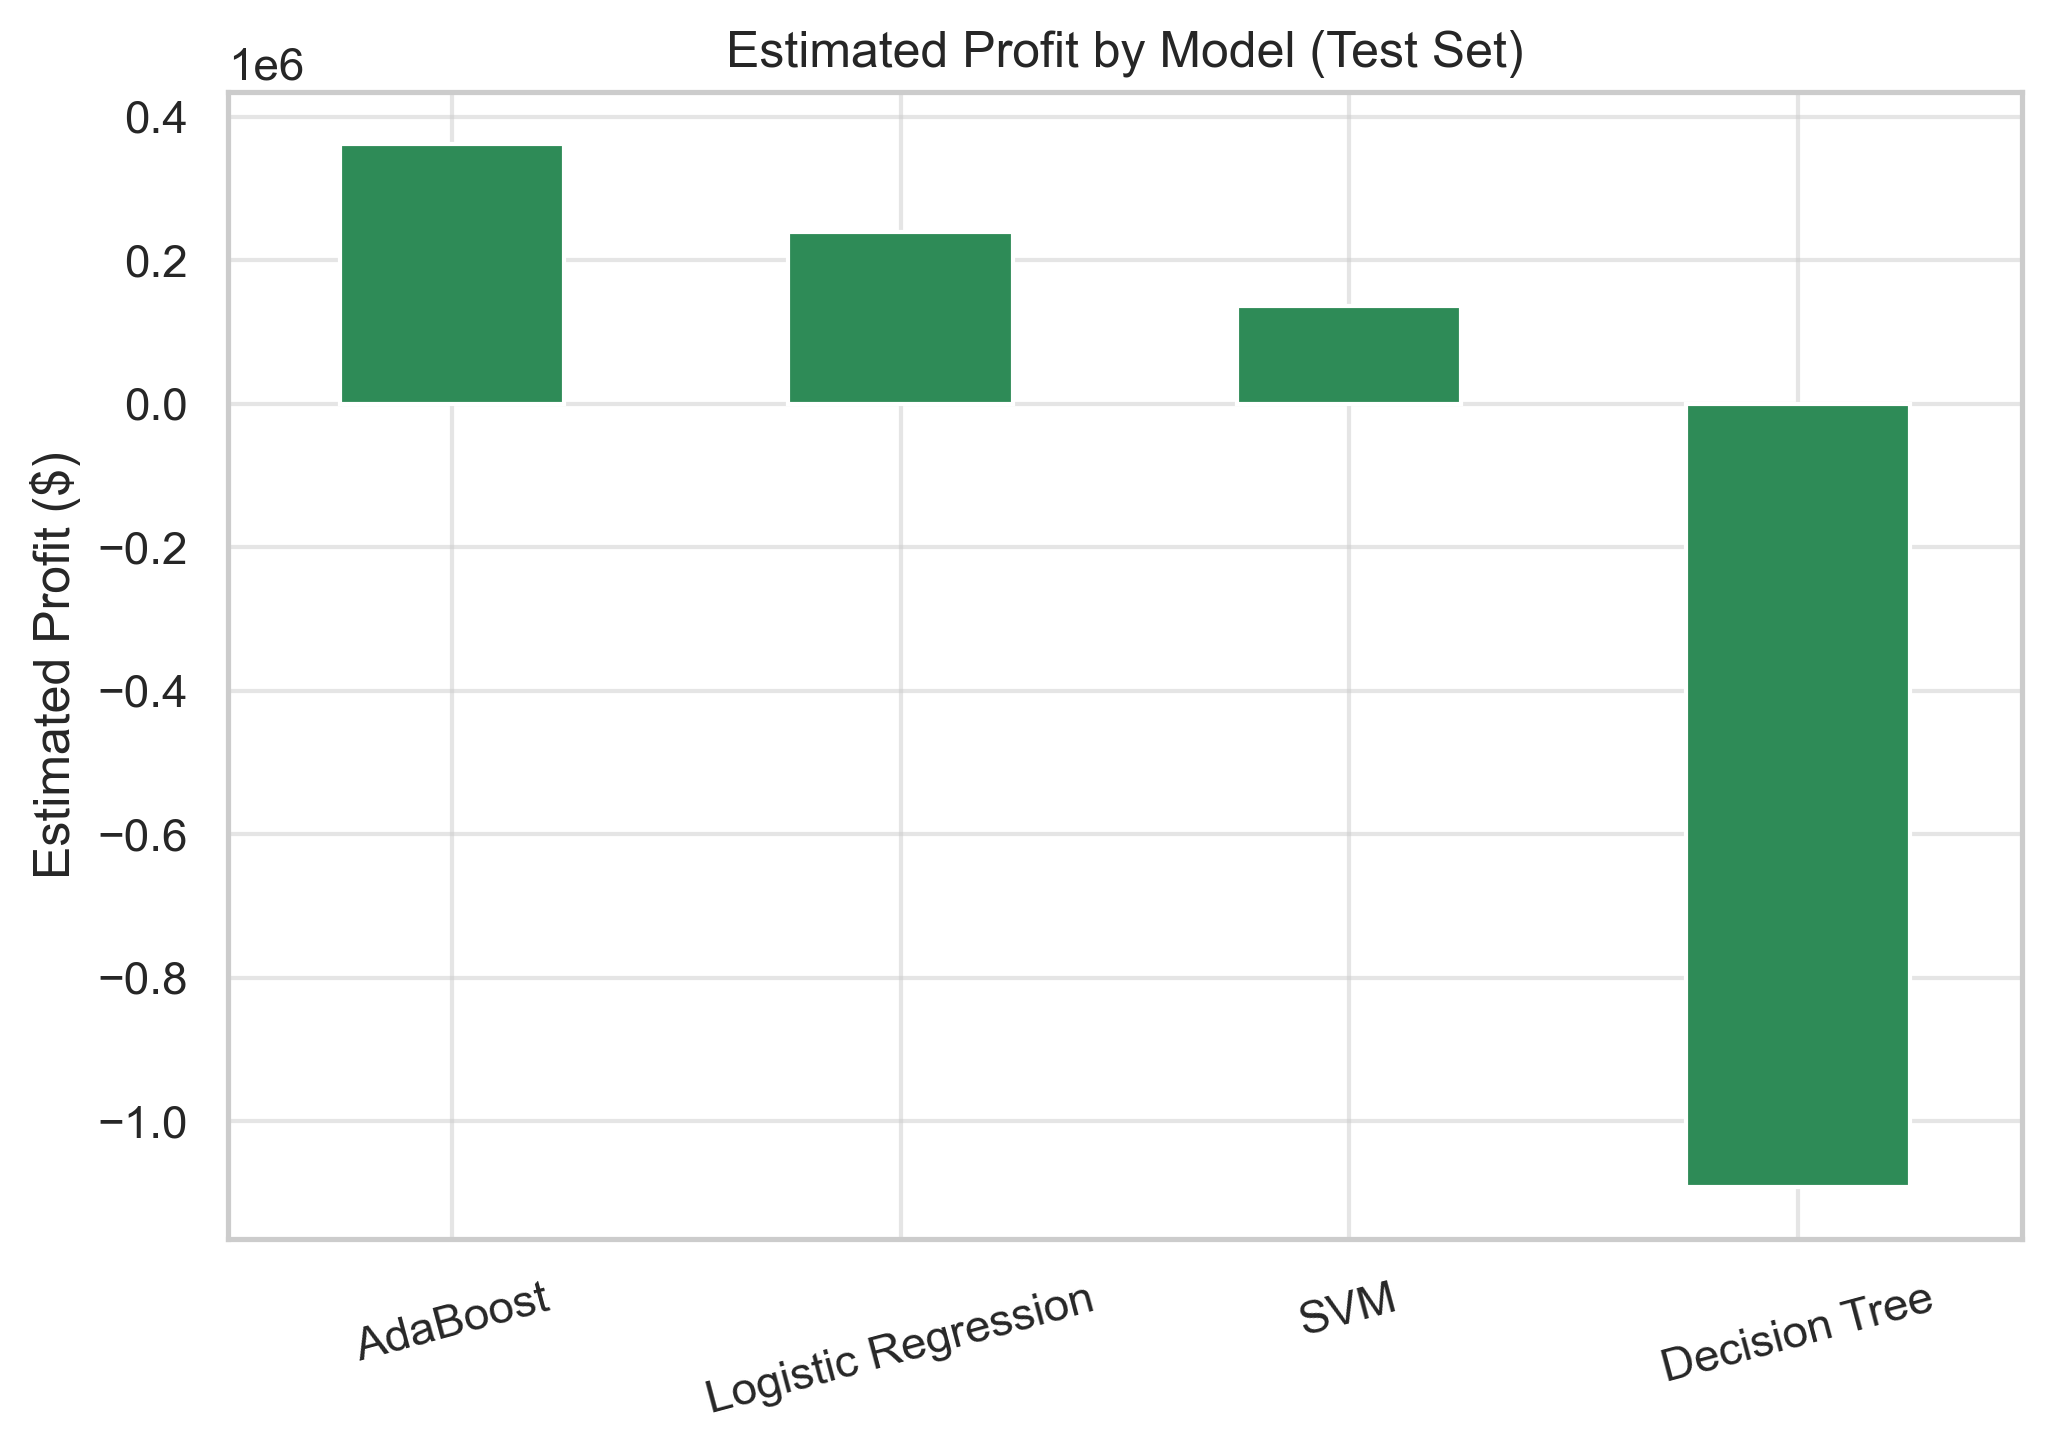

In [30]:
profit_results = {
    name: estimated_profit(y_test, y_pred) for name, y_pred in predictions.items()
}

profit_df = pd.Series(profit_results, name="Estimated Profit ($)").sort_values(ascending=False)
display(profit_df)

profit_df.plot(kind="bar", figsize=(7, 5), color="seagreen")
plt.title("Estimated Profit by Model (Test Set)")
plt.ylabel("Estimated Profit ($)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Which Features Matter Most?

Let's look at which applicant attributes the Decision Tree and AdaBoost models relied on most. (Logistic Regression also has coefficients we could look at, and SVM is harder to interpret because of its kernel — trees make this part easy.)

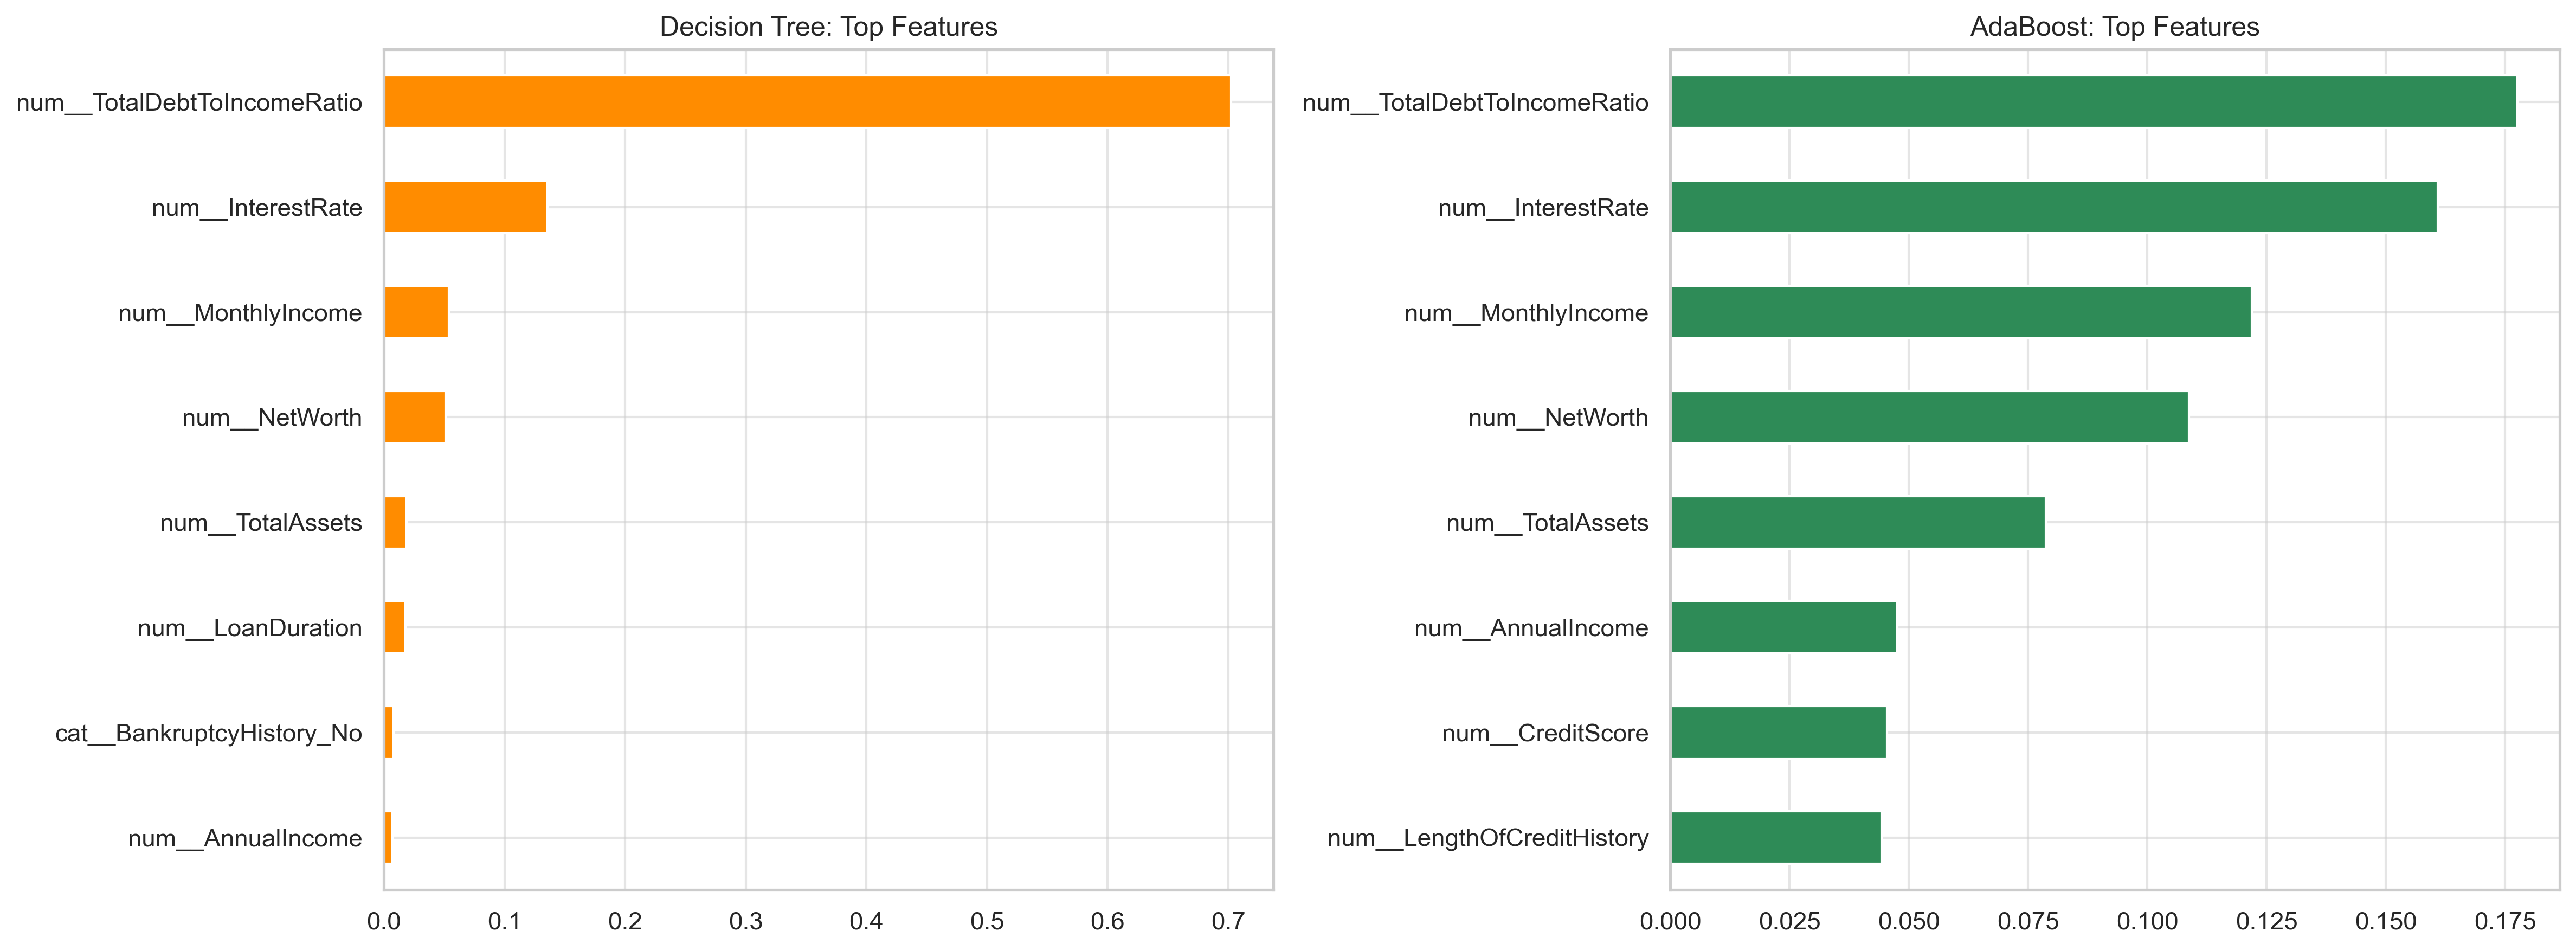

In [31]:
feature_names = best_models["Decision Tree"].named_steps["preprocessor"].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dt_importance = pd.Series(
    best_models["Decision Tree"].named_steps["clf"].feature_importances_, index=feature_names
).sort_values(ascending=False).head(8)
dt_importance.sort_values().plot(kind="barh", ax=axes[0], color="darkorange")
axes[0].set_title("Decision Tree: Top Features")

ab_importance = pd.Series(
    best_models["AdaBoost"].named_steps["clf"].feature_importances_, index=feature_names
).sort_values(ascending=False).head(8)
ab_importance.sort_values().plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("AdaBoost: Top Features")

plt.tight_layout()
plt.show()

### Summary

*To be finalized with the actual numbers produced by running the cells above.*